In [1]:
import sys
import cv2
from matplotlib import pyplot as plt
import numpy as np
import torch
from torch.nn import functional as F
import kornia.geometry.subpix.dsnt as dsnt
from kornia.utils.grid import create_meshgrid
import math
from einops.einops import rearrange
from typing import Sequence
import importlib
from utils.misc import setup_gpus
from default_config import get_cfg_defaults
from maff.maff_v1 import MAFF_v1
from maff.maff_v2 import MAFF_v2
from maff.loss import MAFF_Loss
from maff.utils.supervision import compute_supervision_coarse, compute_supervision_fine
from utils.metrics import (
    compute_symmetrical_epipolar_errors,
    compute_pose_errors,
    aggregate_metrics,
)
from datasets.overall_dataset import MAFF_Dataset

In [ ]:

config = get_cfg_defaults()
config.IMAGE_SIZE = config.MODEL.BACKBONE.INPUT_SIZE = config.DATASET.MGDPT_IMG_RESIZE = 640
config.DEVICE.GPU_IDX = "6,"
config.DEVICE.ENABLE_DDP = False
# setup exact gpus available and set CUDA_VISIBLE_DEVICES variable
n_gpu_available = (
    setup_gpus(config.DEVICE.GPU_IDX) if config.DEVICE.ENABLE_GPU else 0
)
config.TRAINER.WORLD_SIZE = n_gpu_available * config.DEVICE.NUM_NODES
config.TRAINER.TRUE_BATCH_SIZE = (
    config.TRAINER.WORLD_SIZE * config.LOADER.BATCH_SIZE
)
config.TRAINER.SCALING = (
    config.TRAINER.TRUE_BATCH_SIZE / config.TRAINER.CANONICAL_BS
)
config.TRAINER.TRUE_LR = config.TRAINER.CANONICAL_LR * config.TRAINER.SCALING
config.TRAINER.WARMUP_STEP = math.floor(
    config.TRAINER.WARMUP_STEP / config.TRAINER.SCALING
)
device = torch.device("cuda:0")

if config["MODEL"]["VERSION"] == "v1":
    _MAFF = MAFF_v1
elif config["MODEL"]["VERSION"] == "v2":
    _MAFF = MAFF_v2

maff = _MAFF(config=config["MODEL"])
maff.to(device)

data_module = MAFF_Dataset(config=config)
data_module.setup(stage="fit")
train_dataloader = data_module.train_dataloader()
val_dataloader = data_module.val_dataloader()

loss = MAFF_Loss(config["LOSS"])

datas = []

for data in train_dataloader:
    datas.append(data)
    if len(datas) == 20:
        break

In [3]:
def recursive_to(item, device):
    if isinstance(item, torch.Tensor):
        return item.to(device)
    elif isinstance(item, dict):
        return {key: recursive_to(value, device) for key, value in item.items()}
    elif isinstance(item, list):
        return [recursive_to(value, device) for value in item]
    elif isinstance(item, tuple):
        return tuple(recursive_to(value, device) for value in item)
    else:
        return item

def compute_auc(errors, thresholds):
    """
    计算给定误差的 AUC（Area Under the Curve）
    
    Args:
        errors (torch.Tensor): 误差张量
        thresholds (list): AUC 计算的阈值列表
    
    Returns:
        dict: 不同阈值下的 AUC 值
    """
    errors = errors.cpu().numpy()
    sort_idx = np.argsort(errors)
    errors = errors[sort_idx]
    recall = (np.arange(len(errors)) + 1) / len(errors)
    errors = np.r_[0., errors]
    recall = np.r_[0., recall]
    
    aucs = {}
    for t in thresholds:
        last_index = np.searchsorted(errors, t)
        r = np.r_[recall[:last_index], recall[last_index-1]]
        e = np.r_[errors[:last_index], t]
        aucs[f'auc@{t}'] = np.trapz(r, x=e)/t
    
    return aucs

In [4]:
config.TRAINER.RANSAC_CONF = 0.99999
config.TRAINER.RANSAC_PIXEL_THR = 0.5

In [ ]:
data = datas[0]
data = recursive_to(data, device)
compute_supervision_coarse(data, coarse_scale=maff.coarse_scale)
maff(data, training=True)
compute_supervision_fine(data, config=config)

In [6]:
torch.cuda.empty_cache()

In [6]:
loss(data)

In [ ]:
for i in range(1):
    t_errs = []
    R_errs = []
    epi_errs = []

    for data in datas:
        data = recursive_to(data, device)
        compute_supervision_coarse(data, coarse_scale=config.MODEL.COARSE_SCALE)
        W = data["image0"].shape[-1] / config.MODEL.COARSE_SCALE
        if config.MODEL.VERSION == "v1":
            scale = (
                1
                if config["MODEL"]["PIXEL_SHUFFLE_REFINEMENT"]
                else config["MODEL"]["FINE_SCALE"]
            )
        elif config.MODEL.VERSION == "v2":
            scale = (
                1
                if config["MODEL"]["PIXEL_SHUFFLE_REFINEMENT"]
                else config["MODEL"]["BACKBONE"]["RESOLUTION"][0]
            )
        scale0 = data["scale0"] if "scale0" in data else 1
        scale1 = data["scale1"] if "scale1" in data else 1

        data.update(
            {
                "b_idx_c": data["spv_b_ids"],
                "i_idx_c": data["spv_i_ids"],
                "j_idx_c": data["spv_j_ids"],
            }
        )

        with torch.no_grad():
            maff(data, training=True)

        compute_supervision_fine(data, config)
        
        pass

        coarse_coord_0 = data["coarse_coord_0"]
        coarse_coord_1 = data["coarse_coord_1"]
        fine_coord_0 = data["fine_coord_0"].clone().detach()
        fine_coord_1 = data["fine_coord_1"].clone().detach()
        radius = (
            config["MODEL"]["COARSE_SCALE"] / 2
            if config["MODEL"]["PIXEL_SHUFFLE_REFINEMENT"]
            else int(config["MODEL"]["COARSE_SCALE"] // config["MODEL"]["FINE_SCALE"])
            / 2
        )
        mask = (
            torch.linalg.norm(data["coord_offset_f_gt"], ord=float("inf"), dim=1) < 2.0
        )
        data["coord_offset_f_gt"][~mask] = 0
        fine_coord_1 = (
            coarse_coord_1 + data["coord_offset_f_gt"] * scale1 * scale * radius
        )

        data.update(
            {
                "fine_coord_0": fine_coord_0[mask],
                "fine_coord_1": fine_coord_1[mask],
                "b_idx_c": data["b_idx_c"][mask],
            }
        )

        # Errors
        compute_symmetrical_epipolar_errors(data)
        compute_pose_errors(data, config)
        t_errs.append(data["t_errs"])
        R_errs.append(data["R_errs"])
        epi_errs.append(data["epi_errs"])
        torch.cuda.empty_cache()

        # # 从 data 中获取图像并转换为 numpy 数组
        # image0 = data["image0"].detach().cpu().numpy()[0, 0] * 255
        # W1 = data["image0"].shape[-1]
        # image1 = data["image1"].detach().cpu().numpy()[0, 0] * 255

        # # 确保图像数据类型为 uint8
        # image0 = image0.astype(np.uint8)
        # image1 = image1.astype(np.uint8)

        # # 将灰度图像转换为 BGR 图像
        # image0 = cv2.cvtColor(image0, cv2.COLOR_GRAY2RGB)
        # image1 = cv2.cvtColor(image1, cv2.COLOR_GRAY2RGB)

        # # 将图像插值至两倍大小
        # image0 = cv2.resize(
        #     image0,
        #     (image0.shape[1] * 2, image0.shape[0] * 2),
        #     interpolation=cv2.INTER_LINEAR,
        # )
        # image1 = cv2.resize(
        #     image1,
        #     (image1.shape[1] * 2, image1.shape[0] * 2),
        #     interpolation=cv2.INTER_LINEAR,
        # )
        # W1 *= 2

        # # 将两张图像水平拼接在一起
        # combined_image = cv2.hconcat([image0, image1])

        # # 预定义一组常规的颜色
        # colors = [
        #     (255, 0, 0),  # 红色
        #     (0, 255, 0),  # 绿色
        #     (0, 0, 255),  # 蓝色
        #     (255, 255, 0),  # 黄色
        #     (255, 0, 255),  # 洋红
        #     (0, 255, 255),  # 青色
        #     (128, 0, 0),  # 深红
        #     (0, 128, 0),  # 深绿
        #     (0, 0, 128),  # 深蓝
        #     (128, 128, 0),  # 橄榄绿
        #     (128, 0, 128),  # 紫色
        #     (0, 128, 128),  # 青绿色
        #     (192, 192, 192),  # 银色
        #     (128, 128, 128),  # 灰色
        #     (0, 0, 0),  # 黑色
        #     (255, 165, 0),  # 橙色
        #     (255, 20, 147),  # 深粉色
        #     (75, 0, 130),  # 靛蓝色
        #     (240, 230, 140),  # 卡其色
        #     (173, 216, 230),  # 淡蓝色
        # ]

        # # 在图像上绘制连线和圆圈
        # lines = []
        # circles = []

        # for idx, ((x0, y0), (x1, y1)) in enumerate(
        #     zip(fine_coord_0[mask], fine_coord_1[mask])
        # ):
        #     # 从预定义的颜色中随机选择一个颜色
        #     color = (
        #         np.random.randint(0, 256),
        #         np.random.randint(0, 256),
        #         np.random.randint(0, 256),
        #     )

        #     scale0 = data["scale0"][0] if "scale0" in data else 1
        #     scale1 = data["scale1"][0] if "scale1" in data else 1

        #     # 调整坐标至两倍大小
        #     x0, y0, x1, y1 = (
        #         x0 * 2 / scale0[0],
        #         y0 * 2 / scale0[1],
        #         x1 * 2 / scale1[0],
        #         y1 * 2 / scale1[1],
        #     )

        #     # 存储线段信息
        #     lines.append(((int(x0), int(y0)), (int(x1) + W1, int(y1)), color))

        #     # 存储圆圈信息
        #     circles.append(((int(x0), int(y0)), color))
        #     circles.append(((int(x1) + W1, int(y1)), color))

        # # 先绘制所有线段
        # for start, end, color in lines:
        #     cv2.line(combined_image, start, end, color, 1, lineType=cv2.LINE_AA)

        # # 再绘制所有圆圈
        # for center, color in circles:
        #     cv2.circle(combined_image, center, 2, color, -1, lineType=cv2.LINE_AA)

        # # 保存图像到文件
        # output_path = "sample_match.png"
        # cv2.imwrite(output_path, combined_image)

        # # 使用 matplotlib 显示拼接后的图像
        # plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
        # plt.axis("off")  # 关闭坐标轴
        # plt.show()
        # print(f"R_errs: {data['R_errs']}")
        # print(f"t_errs: {data['t_errs']}")

    # Print results
    t_errs = torch.tensor(t_errs).squeeze()
    R_errs = torch.tensor(R_errs).squeeze()
    aucs = [5, 10, 20]
    thres = 1e-4
    R_auc = compute_auc(R_errs, aucs)
    t_auc = compute_auc(t_errs, aucs)
    combined_errs = torch.max(R_errs, t_errs)
    combined_auc = compute_auc(combined_errs, aucs)
    print("\nR AUC:")
    for k, v in R_auc.items():
        print(f"{k}: {v:.4f}")
    print("\nt AUC")
    for k, v in t_auc.items():
        print(f"{k}: {v:.4f}")
    print("\nAUC:")
    for k, v in combined_auc.items():
        print(f"{k}: {v:.4f}")

    correct = 0
    total = 0
    for i in range(len(epi_errs)):
        correct += (epi_errs[i] < thres).sum()
        total += len(epi_errs[i])
    print(f"prec@{thres: e}: \t{((correct / total).item()) * 100 : .4f}")

In [ ]:
t_errs = []
R_errs = []
epi_errs = []

for data in datas:
    data = recursive_to(data, device)
    compute_supervision_coarse(data, coarse_scale=config.MODEL.COARSE_SCALE)
    W = data["image0"].shape[-1] / config.MODEL.COARSE_SCALE
    if config.MODEL.VERSION == "v1":
        scale = (
            1
            if config["MODEL"]["PIXEL_SHUFFLE_REFINEMENT"]
            else config["MODEL"]["FINE_SCALE"]
        )
    elif config.MODEL.VERSION == "v2":
        scale = (
            1
            if config["MODEL"]["PIXEL_SHUFFLE_REFINEMENT"]
            else config["MODEL"]["BACKBONE"]["RESOLUTION"][0]
        )
    scale0 = data["scale0"] if "scale0" in data else 1
    scale1 = data["scale1"] if "scale1" in data else 1
    coarse_coord_0 = torch.tensor(
        [[i % W, i // W] for i in data["spv_i_ids"]], device=device
    )
    coarse_coord_1 = torch.tensor(
        [[i % W, i // W] for i in data["spv_j_ids"]], device=device
    )

    data.update(
        {
            "b_idx_c": data["spv_b_ids"],
            "i_idx_c": data["spv_i_ids"],
            "j_idx_c": data["spv_j_ids"],
        }
    )

    with torch.no_grad():
        maff(data, training=True)

    edited_compute_supervision_fine(data, config)

    coarse_coord_0 = data["coarse_coord_0"]
    coarse_coord_1 = data["coarse_coord_1"]
    fine_coord_0 = data["fine_coord_0"].clone().detach()
    fine_coord_1 = data["fine_coord_1"].clone().detach()
    # 添加固定扰动
    fixed_noise = torch.tensor([[0, 0]], device=device).repeat(
        data["coord_offset_f_gt"].shape[0], 1
    )
    radius = (
        config["MODEL"]["COARSE_SCALE"] / 2
        if config["MODEL"]["PIXEL_SHUFFLE_REFINEMENT"]
        else int(config["MODEL"]["COARSE_SCALE"] // config["MODEL"]["FINE_SCALE"]) / 2
    )
    mask = torch.linalg.norm(data["coord_offset_f_gt"], ord=float("inf"), dim=1) < 2.0
    data["coord_offset_f_gt"][~mask] = 0
    fine_coord_1 = (
        coarse_coord_1
        + (data["coord_offset_f_gt"] + fixed_noise) * scale1 * scale * 4.0
    )

    data.update(
        {
            "fine_coord_0": fine_coord_0[mask],
            "fine_coord_1": fine_coord_1[mask],
            "b_idx_c": data["b_idx_c"][mask],
        }
    )

    # Errors
    compute_symmetrical_epipolar_errors(data)
    compute_pose_errors(data, config)
    t_errs.append(data["t_errs"])
    R_errs.append(data["R_errs"])
    epi_errs.append(data["epi_errs"])
    torch.cuda.empty_cache()

    # # 从 data 中获取图像并转换为 numpy 数组
    # image0 = data["image0"].detach().cpu().numpy()[0, 0] * 255
    # W1 = data["image0"].shape[-1]
    # image1 = data["image1"].detach().cpu().numpy()[0, 0] * 255

    # # 确保图像数据类型为 uint8
    # image0 = image0.astype(np.uint8)
    # image1 = image1.astype(np.uint8)

    # # 将灰度图像转换为 BGR 图像
    # image0 = cv2.cvtColor(image0, cv2.COLOR_GRAY2RGB)
    # image1 = cv2.cvtColor(image1, cv2.COLOR_GRAY2RGB)

    # # 将图像插值至两倍大小
    # image0 = cv2.resize(
    #     image0,
    #     (image0.shape[1] * 2, image0.shape[0] * 2),
    #     interpolation=cv2.INTER_LINEAR,
    # )
    # image1 = cv2.resize(
    #     image1,
    #     (image1.shape[1] * 2, image1.shape[0] * 2),
    #     interpolation=cv2.INTER_LINEAR,
    # )
    # W1 *= 2

    # # 将两张图像水平拼接在一起
    # combined_image = cv2.hconcat([image0, image1])

    # # 预定义一组常规的颜色
    # colors = [
    #     (255, 0, 0),  # 红色
    #     (0, 255, 0),  # 绿色
    #     (0, 0, 255),  # 蓝色
    #     (255, 255, 0),  # 黄色
    #     (255, 0, 255),  # 洋红
    #     (0, 255, 255),  # 青色
    #     (128, 0, 0),  # 深红
    #     (0, 128, 0),  # 深绿
    #     (0, 0, 128),  # 深蓝
    #     (128, 128, 0),  # 橄榄绿
    #     (128, 0, 128),  # 紫色
    #     (0, 128, 128),  # 青绿色
    #     (192, 192, 192),  # 银色
    #     (128, 128, 128),  # 灰色
    #     (0, 0, 0),  # 黑色
    #     (255, 165, 0),  # 橙色
    #     (255, 20, 147),  # 深粉色
    #     (75, 0, 130),  # 靛蓝色
    #     (240, 230, 140),  # 卡其色
    #     (173, 216, 230),  # 淡蓝色
    # ]

    # # 在图像上绘制连线和圆圈
    # lines = []
    # circles = []

    # for idx, ((x0, y0), (x1, y1)) in enumerate(
    #     zip(fine_coord_0[mask], fine_coord_1[mask])
    # ):
    #     # 从预定义的颜色中随机选择一个颜色
    #     color = (
    #         np.random.randint(0, 256),
    #         np.random.randint(0, 256),
    #         np.random.randint(0, 256),
    #     )

    #     scale0 = data["scale0"][0] if "scale0" in data else 1
    #     scale1 = data["scale1"][0] if "scale1" in data else 1

    #     # 调整坐标至两倍大小
    #     x0, y0, x1, y1 = (
    #         x0 * 2 / scale0[0],
    #         y0 * 2 / scale0[1],
    #         x1 * 2 / scale1[0],
    #         y1 * 2 / scale1[1],
    #     )

    #     # 存储线段信息
    #     lines.append(((int(x0), int(y0)), (int(x1) + W1, int(y1)), color))

    #     # 存储圆圈信息
    #     circles.append(((int(x0), int(y0)), color))
    #     circles.append(((int(x1) + W1, int(y1)), color))

    # # 先绘制所有线段
    # for start, end, color in lines:
    #     cv2.line(combined_image, start, end, color, 1, lineType=cv2.LINE_AA)

    # # 再绘制所有圆圈
    # for center, color in circles:
    #     cv2.circle(combined_image, center, 2, color, -1, lineType=cv2.LINE_AA)

    # # 保存图像到文件
    # output_path = "sample_match.png"
    # cv2.imwrite(output_path, combined_image)

    # # 使用 matplotlib 显示拼接后的图像
    # plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
    # plt.axis("off")  # 关闭坐标轴
    # plt.show()
    # print(f"R_errs: {data['R_errs']}")
    # print(f"t_errs: {data['t_errs']}")

# Print results
t_errs = torch.tensor(t_errs).squeeze()
R_errs = torch.tensor(R_errs).squeeze()
aucs = [5, 10, 20]
thres = 1e-4
R_auc = compute_auc(R_errs, aucs)
t_auc = compute_auc(t_errs, aucs)
combined_errs = torch.max(R_errs, t_errs)
combined_auc = compute_auc(combined_errs, aucs)
print("\nR AUC:")
for k, v in R_auc.items():
    print(f"{k}: {v:.4f}")
print("\nt AUC")
for k, v in t_auc.items():
    print(f"{k}: {v:.4f}")
print("\nAUC:")
for k, v in combined_auc.items():
    print(f"{k}: {v:.4f}")


correct = 0
total = 0
for i in range(len(epi_errs)):
    correct += (epi_errs[i] < thres).sum()
    total += len(epi_errs[i])
print(f"prec@{thres: e}: \t{((correct / total).item()) * 100 : .4f}")

In [ ]:
latest_ckpt_path = "logs/tb_logs/MegaDepth_640_(0, 0, 1, 1, 1)_8_2_M2_VMamba_T_FPN_PMF/version_0"
latest_ckpt = "checkpoints/last.ckpt"

sys.path.append(latest_ckpt_path)
get_cfg_defaults = importlib.import_module("config").get_cfg_defaults

In [ ]:
config = get_cfg_defaults()
config.DEVICE.GPU_IDX = "7,"
config.DEVICE.ENABLE_DDP = False
# setup exact gpus available and set CUDA_VISIBLE_DEVICES variable
n_gpu_available = (
    setup_gpus(config.DEVICE.GPU_IDX) if config.DEVICE.ENABLE_GPU else 0
)
config.TRAINER.WORLD_SIZE = n_gpu_available * config.DEVICE.NUM_NODES
config.TRAINER.TRUE_BATCH_SIZE = (
    config.TRAINER.WORLD_SIZE * config.LOADER.BATCH_SIZE
)
config.TRAINER.SCALING = (
    config.TRAINER.TRUE_BATCH_SIZE / config.TRAINER.CANONICAL_BS
)
config.TRAINER.TRUE_LR = config.TRAINER.CANONICAL_LR * config.TRAINER.SCALING
config.TRAINER.WARMUP_STEP = math.floor(
    config.TRAINER.WARMUP_STEP / config.TRAINER.SCALING
)
device = torch.device("cuda:0")

In [ ]:
if config["MODEL"]["VERSION"] == "v1":
    _MAFF = MAFF_v1
elif config["MODEL"]["VERSION"] == "v2":
    _MAFF = MAFF_v2

maff = _MAFF(config=config["MODEL"])
maff.load_state_dict(torch.load(latest_ckpt_path+"/"+latest_ckpt)["state_dict"])
maff.to(device)

In [ ]:
data_module = MAFF_Dataset(config=config)
data_module.setup(stage="fit")
train_dataloader = data_module.train_dataloader()
val_dataloader = data_module.val_dataloader()

In [ ]:
datas = []

for data in train_dataloader:
    datas.append(data)
    if len(datas) == 20:
        break

In [ ]:
def recursive_to(item, device):
    if isinstance(item, torch.Tensor):
        return item.to(device)
    elif isinstance(item, dict):
        return {key: recursive_to(value, device) for key, value in item.items()}
    elif isinstance(item, list):
        return [recursive_to(value, device) for value in item]
    elif isinstance(item, tuple):
        return tuple(recursive_to(value, device) for value in item)
    else:
        return item

In [ ]:
config.TRAINER.RANSAC_CONF = 0.99999
config.TRAINER.RANSAC_PIXEL_THR = 0.2

In [ ]:
def compute_auc(errors, thresholds):
    """
    计算给定误差的 AUC（Area Under the Curve）
    
    Args:
        errors (torch.Tensor): 误差张量
        thresholds (list): AUC 计算的阈值列表
    
    Returns:
        dict: 不同阈值下的 AUC 值
    """
    errors = errors.cpu().numpy()
    sort_idx = np.argsort(errors)
    errors = errors[sort_idx]
    recall = (np.arange(len(errors)) + 1) / len(errors)
    errors = np.r_[0., errors]
    recall = np.r_[0., recall]
    
    aucs = {}
    for t in thresholds:
        last_index = np.searchsorted(errors, t)
        r = np.r_[recall[:last_index], recall[last_index-1]]
        e = np.r_[errors[:last_index], t]
        aucs[f'auc@{t}'] = np.trapz(r, x=e)/t
    
    return aucs

In [ ]:
for data in datas:
    data = recursive_to(data, device)
    compute_supervision_coarse(data, coarse_scale=config.MODEL.COARSE_SCALE)
    W = data["image0"].shape[-1] / config.MODEL.COARSE_SCALE
    scale = (
        1
        if config["MODEL"]["PIXEL_SHUFFLE_REFINEMENT"]
        else config["MODEL"]["FINE_SCALE"]
    )
    scale0 = data["scale0"] if "scale0" in data else 1
    scale1 = data["scale1"] if "scale1" in data else 1
    # coarse_coord_0 = torch.tensor([[i%W + 0.5,i//W + 0.5] for i in data["spv_i_ids"]], device=device)
    # coarse_coord_1 = torch.tensor([[i%W + 0.5,i//W + 0.5] for i in data["spv_j_ids"]], device=device)
    coarse_coord_0 = torch.tensor([[i%W,i//W] for i in data["spv_i_ids"]], device=device)
    coarse_coord_1 = torch.tensor([[i%W,i//W] for i in data["spv_j_ids"]], device=device)
    
    data.update({
        "b_idx_c": data["spv_b_ids"],
        "i_idx_c": data["spv_i_ids"],
        "j_idx_c": data["spv_j_ids"],
    })
    
    compute_supervision_fine(data, config)
    
    fine_coord_0 = coarse_coord_0 * config.MODEL.COARSE_SCALE * scale0
    # 添加随机扰动
    random_noise = torch.randn_like(data["coord_offset_f_gt"], device=device) * 0.  # 0.1 是扰动的强度，可以根据需要调整
    fixed_noise = torch.tensor([[0.0, 0.0]], device=device).repeat(data["coord_offset_f_gt"].shape[0],1)
    radius = (
        config["MODEL"]["COARSE_SCALE"] // 2
        if config["MODEL"]["PIXEL_SHUFFLE_REFINEMENT"]
        else int(config["MODEL"]["COARSE_SCALE"] // config["MODEL"]["FINE_SCALE"]) // 2
    )
    mask = torch.linalg.norm(data["coord_offset_f_gt"], ord=float("inf"), dim=1) < 1.0
    data["coord_offset_f_gt"][~mask] = 0
    fine_coord_1 = coarse_coord_1 * config.MODEL.COARSE_SCALE * scale1 + (data["coord_offset_f_gt"] + random_noise + fixed_noise) * scale1 * scale * radius

    data.update({"coarse_coord_0": coarse_coord_0, "coarse_coord_1": coarse_coord_1, "fine_coord_0": fine_coord_0, "fine_coord_1": fine_coord_1})

    # 从 data 中获取图像并转换为 numpy 数组
    image0 = data["image0"].detach().cpu().numpy()[0, 0] * 255
    W1 = data["image0"].shape[-1] 
    image1 = data["image1"].detach().cpu().numpy()[0, 0] * 255

    # 确保图像数据类型为 uint8
    image0 = image0.astype(np.uint8)
    image1 = image1.astype(np.uint8)

    # 将灰度图像转换为 BGR 图像
    image0 = cv2.cvtColor(image0, cv2.COLOR_GRAY2RGB)
    image1 = cv2.cvtColor(image1, cv2.COLOR_GRAY2RGB)

    # 将图像插值至两倍大小
    image0 = cv2.resize(image0, (image0.shape[1] * 2, image0.shape[0] * 2), interpolation=cv2.INTER_LINEAR)
    image1 = cv2.resize(image1, (image1.shape[1] * 2, image1.shape[0] * 2), interpolation=cv2.INTER_LINEAR)
    W1 *= 2

    # 将两张图像水平拼接在一起
    combined_image = cv2.hconcat([image0, image1])

    # 预定义一组常规的颜色
    colors = [
        (255, 0, 0),    # 红色
        (0, 255, 0),    # 绿色
        (0, 0, 255),    # 蓝色
        (255, 255, 0),  # 黄色
        (255, 0, 255),  # 洋红
        (0, 255, 255),  # 青色
        (128, 0, 0),    # 深红
        (0, 128, 0),    # 深绿
        (0, 0, 128),    # 深蓝
        (128, 128, 0),  # 橄榄绿
        (128, 0, 128),  # 紫色
        (0, 128, 128),  # 青绿色
        (192, 192, 192),# 银色
        (128, 128, 128),# 灰色
        (0, 0, 0),      # 黑色
        (255, 165, 0),  # 橙色
        (255, 20, 147), # 深粉色
        (75, 0, 130),   # 靛蓝色
        (240, 230, 140),# 卡其色
        (173, 216, 230) # 淡蓝色
    ]

    # 在图像上绘制连线和圆圈
    lines = []
    circles = []

    for idx, ((x0, y0), (x1, y1)) in enumerate(zip(fine_coord_0, fine_coord_1)):
        # 从预定义的颜色中随机选择一个颜色
        color = (np.random.randint(0, 256), np.random.randint(0, 256), np.random.randint(0, 256))
        
        scale0 = data["scale0"][0] if "scale0" in data else 1
        scale1 = data["scale1"][0] if "scale1" in data else 1
        
        # 调整坐标至两倍大小
        x0, y0, x1, y1 = x0 * 2 / scale0[0], y0 * 2 / scale0[1], x1 * 2 / scale1[0], y1 * 2 / scale1[1]
        
        # 存储线段信息
        lines.append(((int(x0), int(y0)), (int(x1) + W1, int(y1)), color))
        
        # 存储圆圈信息
        circles.append(((int(x0), int(y0)), color))
        circles.append(((int(x1) + W1, int(y1)), color))

    # 先绘制所有线段
    for start, end, color in lines:
        cv2.line(combined_image, start, end, color, 1, lineType=cv2.LINE_AA)

    # 再绘制所有圆圈
    for center, color in circles:
        cv2.circle(combined_image, center, 2, color, -1, lineType=cv2.LINE_AA)

    # 保存图像到文件
    output_path = 'sample_match.png'
    cv2.imwrite(output_path, combined_image)

    # 使用 matplotlib 显示拼接后的图像
    plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')  # 关闭坐标轴
    plt.show()    

In [ ]:
t_errs = []
R_errs = []
epi_errs = []
fine_coord_0s = []
fine_coord_1s = []
coarse_coord_1s = []
target_fine_coord_0s = []
target_fine_coord_1s = []
target_coarse_coord_1s = []

for data in datas:
    data = recursive_to(data, device)
    with torch.no_grad():
        maff(data)
        torch.cuda.empty_cache()
    coarse_coord_0 = data["coarse_coord_0"]
    coarse_coord_1 = data["coarse_coord_1"]
    fine_coord_0 = data["fine_coord_0"].clone().detach()
    fine_coord_1 = data["fine_coord_1"].clone().detach()
    compute_supervision_coarse(data, coarse_scale=config.MODEL.COARSE_SCALE)
    W = data["image0"].shape[-1] / config.MODEL.COARSE_SCALE
    scale = (
        1
        if config["MODEL"]["PIXEL_SHUFFLE_REFINEMENT"]
        else config["MODEL"]["FINE_SCALE"]
    )
    scale0 = data["scale0"] if "scale0" in data else 1
    scale1 = data["scale1"] if "scale1" in data else 1
    # coarse_coord_0 = torch.tensor([[i%W + 0.5,i//W + 0.5] for i in data["spv_i_ids"]], device=device)
    # coarse_coord_1 = torch.tensor([[i%W + 0.5,i//W + 0.5] for i in data["spv_j_ids"]], device=device)
    # coarse_coord_0 = torch.tensor([[i%W,i//W] for i in data["spv_i_ids"]], device=device)
    # coarse_coord_1 = torch.tensor([[i%W,i//W] for i in data["spv_j_ids"]], device=device)
    target_coarse_coord_0 = torch.tensor([[i%W,i//W] for i in data["i_idx_c"]], device=device)
    target_coarse_coord_1 = torch.tensor([[i%W,i//W] for i in data["j_idx_c"]], device=device)
    
    # data.update({
    #     "b_idx_c": data["spv_b_ids"],
    #     "i_idx_c": data["spv_i_ids"],
    #     "j_idx_c": data["spv_j_ids"],
    # })
    
    compute_supervision_fine(data, config)
    
    # fine_coord_0 = coarse_coord_0 * config.MODEL.COARSE_SCALE * scale0
    target_fine_coord_0 = target_coarse_coord_0 * config.MODEL.COARSE_SCALE * scale0
    # 添加随机扰动
    random_noise = torch.randn_like(data["expec_f_gt"], device=device) * 0.  # 0.1 是扰动的强度，可以根据需要调整
    fixed_noise = torch.tensor([[0.0, 0.0]], device=device).repeat(data["expec_f_gt"].shape[0],1)
    radius = (
        config["MODEL"]["COARSE_SCALE"] // 2
        if config["MODEL"]["PIXEL_SHUFFLE_REFINEMENT"]
        else int(config["MODEL"]["COARSE_SCALE"] // config["MODEL"]["FINE_SCALE"]) // 2
    )
    mask = torch.linalg.norm(data["expec_f_gt"], ord=float("inf"), dim=1) < 1.0
    data["expec_f_gt"][~mask] = 0
    # fine_coord_1 = coarse_coord_1 * config.MODEL.COARSE_SCALE * scale1 + (data["expec_f_gt"] + random_noise + fixed_noise) * scale1 * scale * radius
    target_fine_coord_1 = target_coarse_coord_1 * config.MODEL.COARSE_SCALE * scale1 + (data["expec_f_gt"] + random_noise + fixed_noise) * scale1 * scale * radius
    
    fine_coord_0s.append(fine_coord_0[mask])
    fine_coord_1s.append(fine_coord_1[mask])
    target_fine_coord_0s.append(target_fine_coord_0[mask])
    target_fine_coord_1s.append(target_fine_coord_1[mask])
    coarse_coord_1s.append(coarse_coord_1[mask])
    target_coarse_coord_1s.append(target_coarse_coord_1[mask])
    # fine_coord_1 = coarse_coord_1 * config.MODEL.COARSE_SCALE * scale1
    # data.update({"coarse_coord_0": coarse_coord_0, "coarse_coord_1": coarse_coord_1, "fine_coord_0": fine_coord_0, "fine_coord_1": fine_coord_1})

    # # 从 data 中获取图像并转换为 numpy 数组
    # image0 = data["image0"].detach().cpu().numpy()[0, 0] * 255
    # W1 = data["image0"].shape[-1] 
    # image1 = data["image1"].detach().cpu().numpy()[0, 0] * 255

    # # 确保图像数据类型为 uint8
    # image0 = image0.astype(np.uint8)
    # image1 = image1.astype(np.uint8)

    # # 将灰度图像转换为 BGR 图像
    # image0 = cv2.cvtColor(image0, cv2.COLOR_GRAY2BGR)
    # image1 = cv2.cvtColor(image1, cv2.COLOR_GRAY2BGR)

    # # 将图像插值至两倍大小
    # image0 = cv2.resize(image0, (image0.shape[1] * 2, image0.shape[0] * 2), interpolation=cv2.INTER_LINEAR)
    # image1 = cv2.resize(image1, (image1.shape[1] * 2, image1.shape[0] * 2), interpolation=cv2.INTER_LINEAR)
    # W1 *= 2

    # # 将两张图像水平拼接在一起
    # combined_image = cv2.hconcat([image0, image1])

    # # 预定义一组常规的颜色
    # colors = [
    #     (255, 0, 0),    # 红色
    #     (0, 255, 0),    # 绿色
    #     (0, 0, 255),    # 蓝色
    #     (255, 255, 0),  # 黄色
    #     (255, 0, 255),  # 洋红
    #     (0, 255, 255),  # 青色
    #     (128, 0, 0),    # 深红
    #     (0, 128, 0),    # 深绿
    #     (0, 0, 128),    # 深蓝
    #     (128, 128, 0),  # 橄榄绿
    #     (128, 0, 128),  # 紫色
    #     (0, 128, 128),  # 青绿色
    #     (192, 192, 192),# 银色
    #     (128, 128, 128),# 灰色
    #     (0, 0, 0),      # 黑色
    #     (255, 165, 0),  # 橙色
    #     (255, 20, 147), # 深粉色
    #     (75, 0, 130),   # 靛蓝色
    #     (240, 230, 140),# 卡其色
    #     (173, 216, 230) # 淡蓝色
    # ]

    # # 在图像上绘制连线和圆圈
    # lines = []
    # circles = []

    # for idx, ((x0, y0), (x1, y1)) in enumerate(zip(fine_coord_0, fine_coord_1)):
    #     # 从预定义的颜色中随机选择一个颜色
    #     color = (np.random.randint(0, 256), np.random.randint(0, 256), np.random.randint(0, 256))
        
    #     scale0 = data["scale0"][0] if "scale0" in data else 1
    #     scale1 = data["scale1"][0] if "scale1" in data else 1
        
    #     # 调整坐标至两倍大小
    #     x0, y0, x1, y1 = x0 * 2 / scale0[0], y0 * 2 / scale0[1], x1 * 2 / scale1[0], y1 * 2 / scale1[1]
        
    #     # 存储线段信息
    #     lines.append(((int(x0), int(y0)), (int(x1) + W1, int(y1)), color))
        
    #     # 存储圆圈信息
    #     circles.append(((int(x0), int(y0)), color))
    #     circles.append(((int(x1) + W1, int(y1)), color))

    # # 先绘制所有线段
    # for start, end, color in lines:
    #     cv2.line(combined_image, start, end, color, 1, lineType=cv2.LINE_AA)

    # # 再绘制所有圆圈
    # for center, color in circles:
    #     cv2.circle(combined_image, center, 2, color, -1, lineType=cv2.LINE_AA)

    # # 保存图像到文件
    # output_path = 'sample_match.png'
    # cv2.imwrite(output_path, combined_image)

    # # 使用 matplotlib 显示拼接后的图像
    # plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
    # plt.axis('off')  # 关闭坐标轴
    # plt.show()    
    
    b_idx_c = torch.zeros(len(fine_coord_0), dtype=torch.int32)
    data.update({"b_idx_c": b_idx_c})
    compute_symmetrical_epipolar_errors(data)
    compute_pose_errors(data, config)
    # print(f"t_errs: {data['t_errs']}\nR_errs: {data['R_errs']}")
    t_errs.append(data['t_errs'])
    R_errs.append(data['R_errs'])
    epi_errs.append(data['epi_errs'])
    torch.cuda.empty_cache()

# Print results
t_errs = torch.tensor(t_errs).squeeze()
R_errs = torch.tensor(R_errs).squeeze()
aucs = [5, 10, 20]
thres = 1e-4
R_auc = compute_auc(R_errs, aucs)
t_auc = compute_auc(t_errs, aucs)
combined_errs = torch.max(R_errs, t_errs)
combined_auc = compute_auc(combined_errs, aucs)
print("\nR AUC:")
for k, v in R_auc.items():
    print(f"{k}: {v:.4f}")
print("\nt AUC")
for k, v in t_auc.items():
    print(f"{k}: {v:.4f}")
print("\nAUC:")
for k, v in combined_auc.items():
    print(f"{k}: {v:.4f}")


correct = 0
total = 0
for i in range(len(epi_errs)):
    correct += (epi_errs[i] < thres).sum()
    total += len(epi_errs[i])
print(f"prec@{thres: e}: \t{((correct / total).item()) * 100 : .4f}")

In [ ]:
fine_coord_0s = torch.concat(fine_coord_0s, dim=0)
fine_coord_1s = torch.concat(fine_coord_1s, dim=0)
coarse_coord_1s = torch.concat(coarse_coord_1s, dim=0)
target_fine_coord_0s = torch.concat(target_fine_coord_0s, dim=0)
target_fine_coord_1s = torch.concat(target_fine_coord_1s, dim=0)
target_coarse_coord_1s = torch.concat(target_coarse_coord_1s, dim=0)

In [ ]:
diff = (fine_coord_1s - coarse_coord_1s)
diff_x = diff[:,0] ** 2
diff_y = diff[:,1] ** 2
print(f"diff_x: {diff_x.mean()}\ndiff_y: {diff_y.mean()}")

In [ ]:
diff = (fine_coord_1s - target_fine_coord_1s)
diff_x = diff[:,0] ** 2
diff_y = diff[:,1] ** 2
print(f"diff_x: {diff_x.mean()}\ndiff_y: {diff_y.mean()}")

In [ ]:
data["expec_f"][0]

In [ ]:
with torch.no_grad():
    compute_supervision_coarse(data, coarse_scale=config.MODEL.COARSE_SCALE)
    maff(data)
    # compute epi_errs for each match
    compute_symmetrical_epipolar_errors(data)
    # compute R_errs, t_errs, pose_errs for each pair
    compute_pose_errors(data, config)
    rel_pair_names = list(zip(*data["pair_names"]))
    bs = data["image0"].size(0)
    metrics = {
        # to filter duplicate pairs caused by DistributedSampler
        "identifiers": ["#".join(rel_pair_names[b]) for b in range(bs)],
        "epi_errs": [
            data["epi_errs"][data["b_idx_c"] == b].cpu().numpy() for b in range(bs)
        ],
        "R_errs": data["R_errs"],
        "t_errs": data["t_errs"],
        "inliers": data["inliers"],
    }
    val_metrics_4tb = aggregate_metrics(metrics, 1e-4)

In [ ]:
print(f"t_errs: {data['t_errs']}\nR_errs: {data['R_errs']}\nInliers: {data['inliers']}")

In [ ]:
coarse_coord_0 = data["coarse_coord_0"]
coarse_coord_1 = data["coarse_coord_1"]
fine_coord_0 = data["fine_coord_0"]
fine_coord_1 = data["fine_coord_1"]

In [ ]:
# 从 data 中获取图像并转换为 numpy 数组
image0 = data["image0"].detach().cpu().numpy()[0, 0] * 255
W1 = data["hw0_i"][1]
image1 = data["image1"].detach().cpu().numpy()[0, 0] * 255

# 确保图像数据类型为 uint8
image0 = image0.astype(np.uint8)
image1 = image1.astype(np.uint8)

# 将灰度图像转换为 BGR 图像
image0 = cv2.cvtColor(image0, cv2.COLOR_GRAY2BGR)
image1 = cv2.cvtColor(image1, cv2.COLOR_GRAY2BGR)

# 将图像插值至两倍大小
image0 = cv2.resize(image0, (image0.shape[1] * 2, image0.shape[0] * 2), interpolation=cv2.INTER_LINEAR)
image1 = cv2.resize(image1, (image1.shape[1] * 2, image1.shape[0] * 2), interpolation=cv2.INTER_LINEAR)
W1 *= 2

# 将两张图像水平拼接在一起
combined_image = cv2.hconcat([image0, image1])

# 预定义一组常规的颜色
colors = [
    (255, 0, 0),    # 红色
    (0, 255, 0),    # 绿色
    (0, 0, 255),    # 蓝色
    (255, 255, 0),  # 黄色
    (255, 0, 255),  # 洋红
    (0, 255, 255),  # 青色
    (128, 0, 0),    # 深红
    (0, 128, 0),    # 深绿
    (0, 0, 128),    # 深蓝
    (128, 128, 0),  # 橄榄绿
    (128, 0, 128),  # 紫色
    (0, 128, 128),  # 青绿色
    (192, 192, 192),# 银色
    (128, 128, 128),# 灰色
    (0, 0, 0),      # 黑色
    (255, 165, 0),  # 橙色
    (255, 20, 147), # 深粉色
    (75, 0, 130),   # 靛蓝色
    (240, 230, 140),# 卡其色
    (173, 216, 230) # 淡蓝色
]

# 在图像上绘制连线和圆圈
lines = []
circles = []

for idx, ((x0, y0), (x1, y1)) in enumerate(zip(fine_coord_0, fine_coord_1)):
    if data["inliers"][0][idx] == 0:
        continue
    # 从预定义的颜色中随机选择一个颜色
    color = (np.random.randint(0, 256), np.random.randint(0, 256), np.random.randint(0, 256))
    
    scale0 = data["scale0"][0] if "scale0" in data else 1
    scale1 = data["scale1"][0] if "scale1" in data else 1
    
    # 调整坐标至两倍大小
    x0, y0, x1, y1 = x0 * 2 / scale0[0], y0 * 2 / scale0[1], x1 * 2 / scale1[0], y1 * 2 / scale1[1]
    
    # 存储线段信息
    lines.append(((int(x0), int(y0)), (int(x1) + W1, int(y1)), color))
    
    # 存储圆圈信息
    circles.append(((int(x0), int(y0)), color))
    circles.append(((int(x1) + W1, int(y1)), color))

# 先绘制所有线段
for start, end, color in lines:
    cv2.line(combined_image, start, end, color, 1, lineType=cv2.LINE_AA)

# 再绘制所有圆圈
for center, color in circles:
    cv2.circle(combined_image, center, 2, color, -1, lineType=cv2.LINE_AA)

# 保存图像到文件
output_path = 'sample_match.png'
cv2.imwrite(output_path, combined_image)

# 使用 matplotlib 显示拼接后的图像
plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
plt.axis('off')  # 关闭坐标轴
plt.show()

In [ ]:
import torch
import math
import torch.nn as nn
from torch.nn import functional as F
from maff.backbone import build_backbone
from default_config import get_cfg_defaults
from utils.misc import setup_gpus

size=640

config = get_cfg_defaults()
config.DEVICE.GPU_IDX = "5,"
config.DEVICE.ENABLE_DDP = False
# setup exact gpus available and set CUDA_VISIBLE_DEVICES variable
n_gpu_available = (
    setup_gpus(config.DEVICE.GPU_IDX) if config.DEVICE.ENABLE_GPU else 0
)
config.TRAINER.WORLD_SIZE = n_gpu_available * config.DEVICE.NUM_NODES
config.TRAINER.TRUE_BATCH_SIZE = (
    config.TRAINER.WORLD_SIZE * config.LOADER.BATCH_SIZE
)
config.TRAINER.SCALING = (
    config.TRAINER.TRUE_BATCH_SIZE / config.TRAINER.CANONICAL_BS
)
config.TRAINER.TRUE_LR = config.TRAINER.CANONICAL_LR * config.TRAINER.SCALING
config.TRAINER.WARMUP_STEP = math.floor(
    config.TRAINER.WARMUP_STEP / config.TRAINER.SCALING
)
config.MODEL.BACKBONE.INPUT_SIZE = size
device = torch.device("cuda:0")
backbone = build_backbone(config["MODEL"]["BACKBONE"]).to(device)
x = torch.randn(size=(1, 1, size, size)).to(device)
with torch.no_grad():
    y = backbone(x)
    for f in y:
        print(f.shape)
del backbone
torch.cuda.empty_cache()

In [ ]:
import torch
from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    CosineAnnealingWarmRestarts,
    StepLR,
    OneCycleLR,
)
import torch.nn as nn
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import tqdm

model = resnet18(pretrained=False)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

mode = "cosineAnnWarm"
# mode = 'cosineAnn'
if mode == "cosineAnn":
    scheduler = CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-5)
elif mode == "cosineAnnWarm":
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=3000, T_mult=2, eta_min=1e-8)
plt.figure()
max_epoch = 1
iters = 5000
cur_lr_list = []
for epoch in range(max_epoch):
    for batch in range(iters):
        optimizer.step()
        scheduler.step()
        cur_lr = optimizer.param_groups[-1]["lr"]
        cur_lr_list.append(cur_lr)
x_list = list(range(len(cur_lr_list)))
plt.plot(x_list, cur_lr_list)
plt.show()

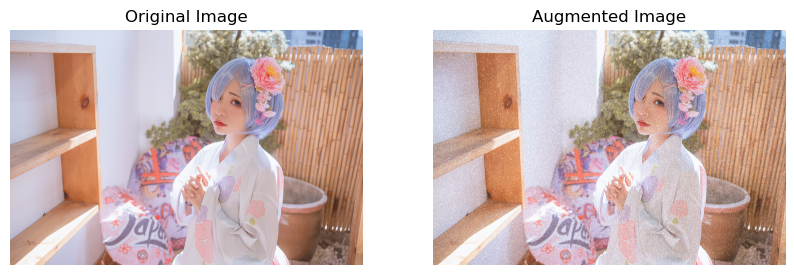

In [6]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A


# 定义 Spatter 增强
class Spatter:
    def __init__(self):
        self.augmentor = A.Compose(
            [
                A.Spatter(p=1.0, mode="rain"),
            ]
        )

    def __call__(self, x):
        return self.augmentor(image=x)["image"]


# 读取图像
image_path = "test.jpg"  # 替换为你的图像路径
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # 转换为 RGB 格式

# 应用 Spatter 增强
spatter_transform = Spatter()
augmented_image = spatter_transform(image)

# 显示原始图像和增强后的图像
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Augmented Image")
plt.imshow(augmented_image)
plt.axis("off")

plt.show()